In [4]:
# ─────────────────────────────────────────────────────────────
# Movie Feelings dataset
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

MOVIE_PATH  = "movie_feelings_dataset.csv"
SYN_PATH    = "synonyms_of_feelings.csv"


In [5]:
# ─────────────────────────────────────────────────────────────
# TASK 1 – Data Collection & Dataset Understanding
# ─────────────────────────────────────────────────────────────
print("=" * 65)
print("TASK 1 — Data Collection & Dataset Understanding")
print("=" * 65)

df_raw   = pd.read_csv(MOVIE_PATH)
df_syn   = pd.read_csv(SYN_PATH)

print(f"\nDataset shape : {df_raw.shape[0]} movies × {df_raw.shape[1]} columns")
print(f"Year range    : {df_raw['year'].min()} – {df_raw['year'].max()}")

# Column groups
meta_cols = ["imdb_id", "title", "year", "title_year", "plot",
             "imdb_rating", "tomatometer", "metascore", "avg_rating"]
f1_cols   = [c for c in df_raw.columns if c.startswith("f1_")]
f2_cols   = [c for c in df_raw.columns if c.startswith("f2_")]
f3_cols   = [c for c in df_raw.columns if c.startswith("f3_")]
label_cols= ["plot_feelings", "gpt_feelings"]

print(f"\nColumn breakdown:")
print(f"  Metadata columns         : {len(meta_cols)}")
print(f"  f1 emotion scores (plot) : {len(f1_cols)}")
print(f"  f2 emotion flags (plot)  : {len(f2_cols)}")
print(f"  f3 emotion flags (GPT)   : {len(f3_cols)}")
print(f"  Label columns            : {len(label_cols)}")

print(f"\nData types summary:")
print(df_raw[meta_cols].dtypes.to_string())

print(f"\nRating statistics:")
print(df_raw[["imdb_rating", "tomatometer", "metascore", "avg_rating"]].describe().round(2).to_string())

print(f"\nSynonyms dataset: {df_syn.shape[0]-1} synonym rows × {df_syn.shape[1]} emotion columns")
print("Emotions covered:", ", ".join(df_syn.columns.tolist()[:8]), "...")



TASK 1 — Data Collection & Dataset Understanding

Dataset shape : 1500 movies × 161 columns
Year range    : 1920 – 2024

Column breakdown:
  Metadata columns         : 9
  f1 emotion scores (plot) : 50
  f2 emotion flags (plot)  : 50
  f3 emotion flags (GPT)   : 50
  Label columns            : 2

Data types summary:
imdb_id         object
title           object
year             int64
title_year      object
plot            object
imdb_rating      int64
tomatometer    float64
metascore      float64
avg_rating     float64

Rating statistics:
       imdb_rating  tomatometer  metascore  avg_rating
count      1500.00      1474.00    1331.00     1500.00
mean         74.15        85.58      75.02       77.53
std           6.24        13.52      14.26        8.86
min          44.00         9.00      16.00       29.50
25%          70.00        81.00      66.00       73.00
50%          75.00        90.00      77.00       79.00
75%          79.00        95.00      86.00       83.75
max          93

In [6]:

# ─────────────────────────────────────────────────────────────
# TASK 2 – Data Cleaning & Preprocessing
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TASK 2 — Data Cleaning & Preprocessing")
print("=" * 65)

df = df_raw.copy()

# --- missing values ---
missing_before = df.isnull().sum()
missing_cols   = missing_before[missing_before > 0]
print(f"\nColumns with missing values ({len(missing_cols)}):")
print(missing_cols.to_string())

# Fill numeric rating NaNs with column medians
for col in ["tomatometer", "metascore", "avg_rating"]:
    median = df[col].median()
    df[col].fillna(median, inplace=True)

# Drop rows where plot is missing (can't analyse feelings without text)
df.dropna(subset=["plot"], inplace=True)

# Fill remaining f-score NaNs with 0 (no signal = 0 probability)
f_all = f1_cols + f2_cols + f3_cols
df[f_all] = df[f_all].fillna(0)

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")

# --- duplicates ---
dup_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed : {dup_before}")

# --- formatting ---
df["year"] = df["year"].astype(int)
df["title"] = df["title"].str.strip()

# Parse plot_feelings into clean list column
df["plot_feelings_list"] = (
    df["plot_feelings"]
    .fillna("")
    .str.split(r",\s*")
    .apply(lambda x: [e.strip().lower() for e in x if e.strip()])
)

# Parse gpt_feelings similarly
df["gpt_feelings_list"] = (
    df["gpt_feelings"]
    .fillna("")
    .str.split(r",\s*")
    .apply(lambda x: [e.strip().lower() for e in x if e.strip()])
)

print(f"\nClean dataset shape: {df.shape}")
print("Sample cleaned plot_feelings:", df["plot_feelings_list"].iloc[0])
print("Sample cleaned gpt_feelings :", df["gpt_feelings_list"].iloc[0])


TASK 2 — Data Cleaning & Preprocessing

Columns with missing values (52):
tomatometer          26
metascore           169
f1_skepticism        27
f1_serenity          27
f1_fear              27
f1_disgust           27
f1_solidarity        27
f1_elation           27
f1_envy              27
f1_puzzlement        27
f1_recklessness      27
f1_loyalty           27
f1_trust             27
f1_sadness           27
f1_shame             27
f1_catharsis         27
f1_unease            27
f1_introspection     27
f1_excitement        27
f1_riskiness         27
f1_mischief          27
f1_enlightenment     27
f1_love              27
f1_tension           27
f1_sarcasm           27
f1_frustration       27
f1_longing           27
f1_awe               27
f1_defiance          27
f1_amusement         27
f1_vulnerability     27
f1_surprise          27
f1_compassion        27
f1_resentment        27
f1_triumph           27
f1_happiness         27
f1_acceptance        27
f1_bravery           27
f1_hope      

In [7]:
# ─────────────────────────────────────────────────────────────
# TASK 3 – Exploratory Data Analysis
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TASK 3 — Exploratory Data Analysis (EDA)")
print("=" * 65)

# --- Basic stats ---
print("\nRating distributions (cleaned):")
print(df[["imdb_rating","tomatometer","metascore","avg_rating"]].describe().round(2).to_string())

# --- Top emotions from f1 scores (continuous, richer signal) ---
emotion_means = df[f1_cols].mean().sort_values(ascending=False)
top_emotions  = emotion_means.head(10)
print("\nTop 10 average f1 emotions across all movies:")
for e, v in top_emotions.items():
    print(f"  {e.replace('f1_',''):<18} {v:.4f}")

# --- Correlation between ratings ---
rating_corr = df[["imdb_rating","tomatometer","metascore","avg_rating"]].corr()
print("\nRating correlation matrix:")
print(rating_corr.round(3).to_string())

# --- Most common emotions in GPT labels ---
from collections import Counter
all_gpt = [e for lst in df["gpt_feelings_list"] for e in lst]
gpt_counts = Counter(all_gpt).most_common(10)
print("\nTop 10 emotions in GPT labels:")
for e, c in gpt_counts:
    print(f"  {e:<18} {c}")

# --- Decade distribution ---
df["decade"] = (df["year"] // 10 * 10).astype(str) + "s"
decade_counts = df["decade"].value_counts().sort_index()
print("\nMovies per decade:")
print(decade_counts.to_string())

# --- High-rated movies (avg_rating >= 80) ---
high_rated = df[df["avg_rating"] >= 80]
print(f"\nMovies with avg_rating ≥ 80: {len(high_rated)}")
dominant_emotion_high = df.loc[high_rated.index, f1_cols].mean().idxmax().replace("f1_", "")
dominant_emotion_all  = emotion_means.idxmax().replace("f1_", "")
print(f"Most dominant emotion in high-rated movies: {dominant_emotion_high}")
print(f"Most dominant emotion overall             : {dominant_emotion_all}")




TASK 3 — Exploratory Data Analysis (EDA)

Rating distributions (cleaned):
       imdb_rating  tomatometer  metascore  avg_rating
count      1500.00      1500.00    1500.00     1500.00
mean         74.15        85.66      75.25       77.53
std           6.24        13.42      13.44        8.86
min          44.00         9.00      16.00       29.50
25%          70.00        81.00      68.00       73.00
50%          75.00        90.00      77.00       79.00
75%          79.00        95.00      85.00       83.75
max          93.00       100.00     100.00       95.25

Top 10 average f1 emotions across all movies:
  anger              0.2462
  amusement          0.1408
  awe                0.1181
  surprise           0.0967
  tension            0.0936
  trust              0.0914
  fear               0.0857
  solidarity         0.0782
  hope               0.0711
  excitement         0.0703

Rating correlation matrix:
             imdb_rating  tomatometer  metascore  avg_rating
imdb_rating   


TASK 4 — Data Visualization


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/task4_visualizations.png'

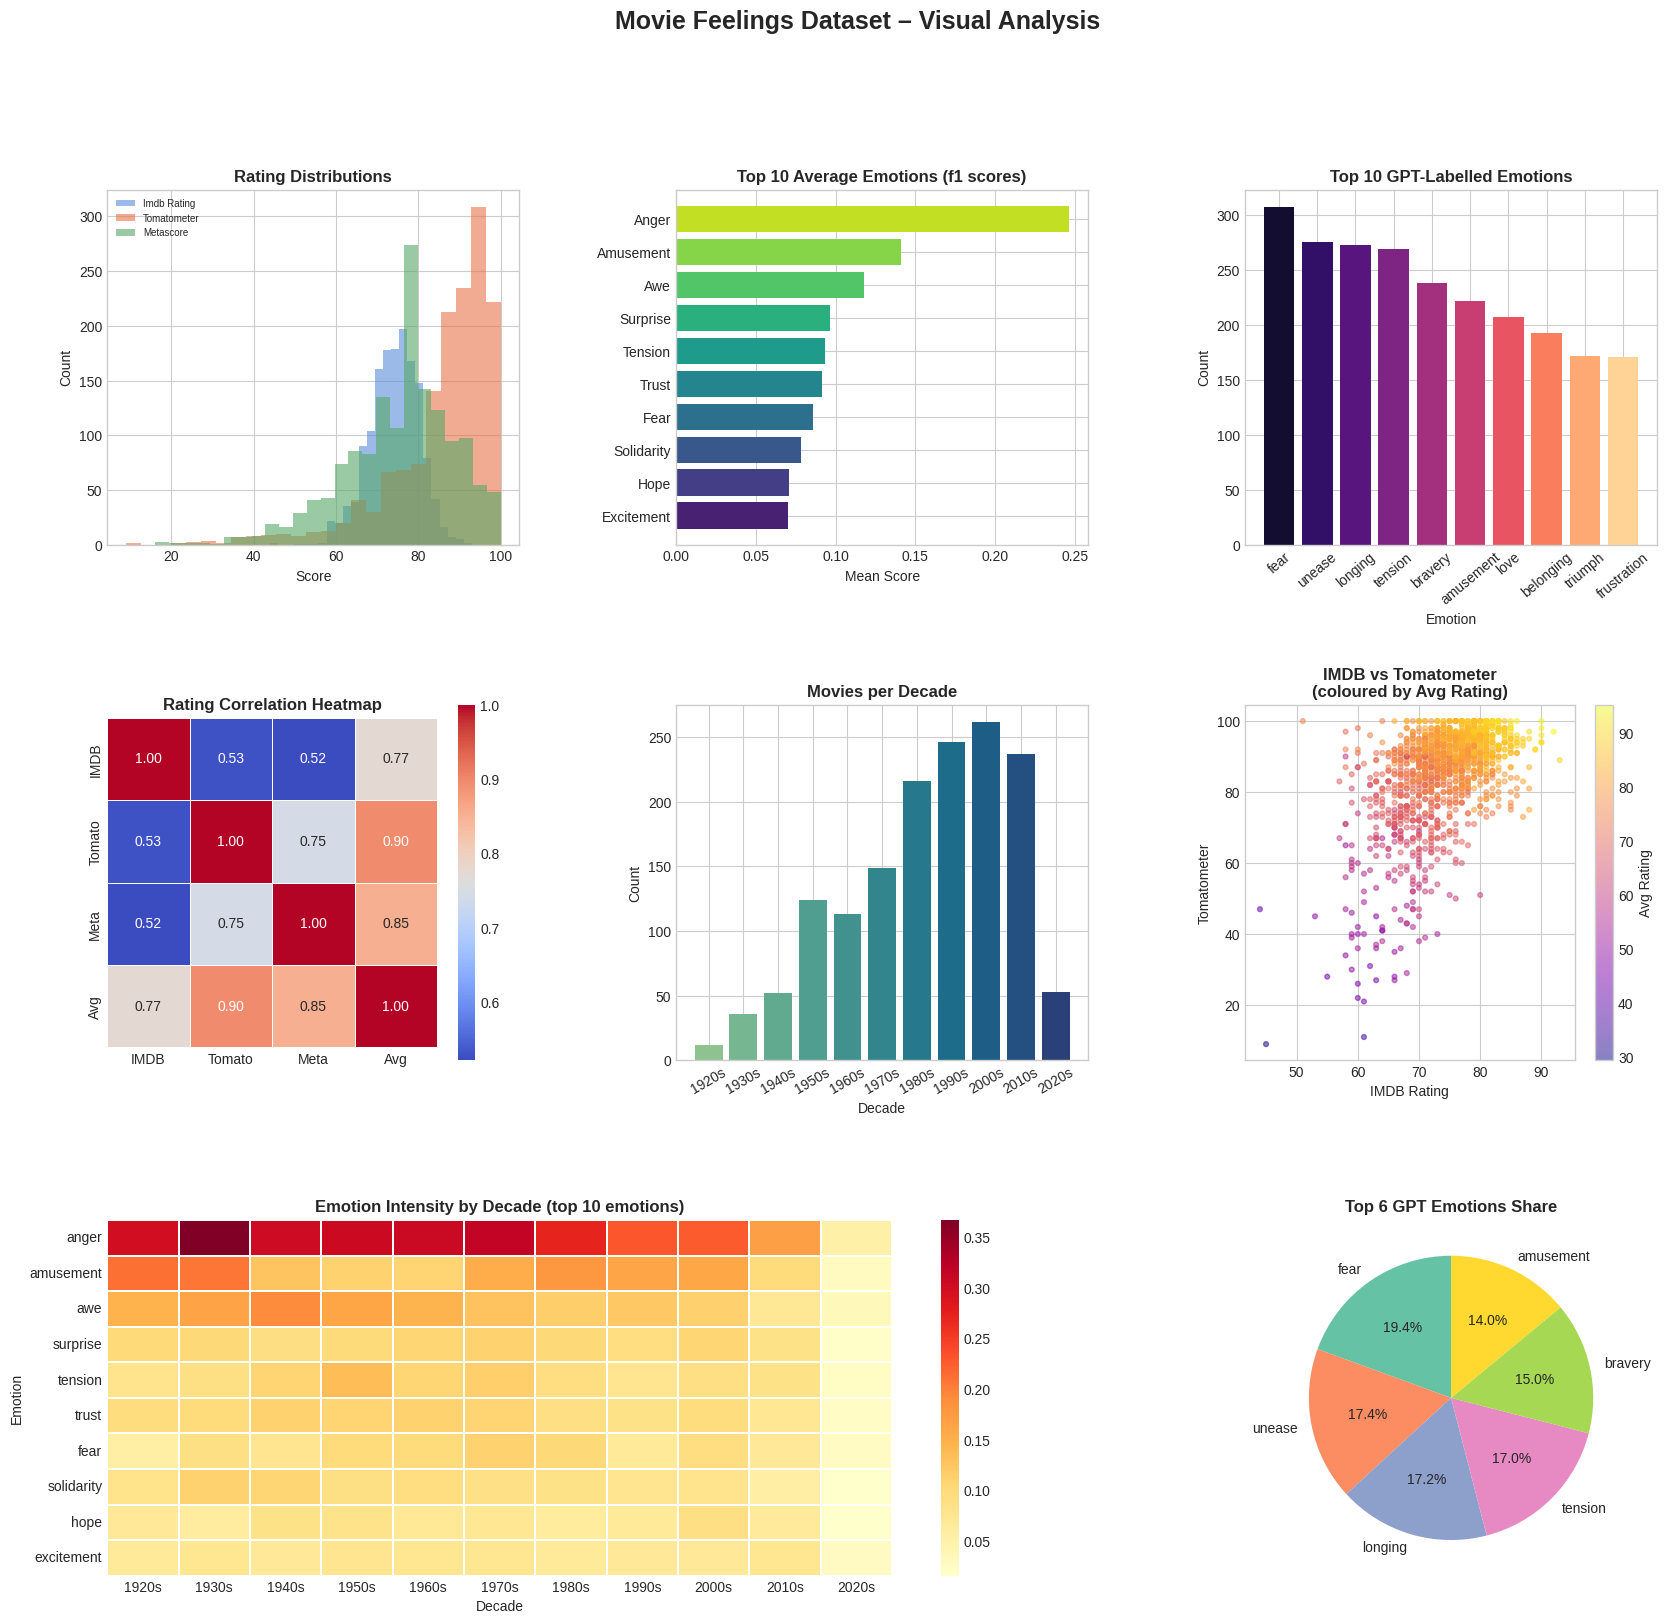

In [10]:

# ─────────────────────────────────────────────────────────────
# TASK 4 – Data Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TASK 4 — Data Visualization")
print("=" * 65)

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Movie Feelings Dataset – Visual Analysis", fontsize=18, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

PALETTE = "viridis"

# 1. Rating distributions (histograms)
ax1 = fig.add_subplot(gs[0, 0])
for col, color in zip(["imdb_rating","tomatometer","metascore"],
                      ["#5b8dd9","#e8734a","#55a868"]):
    ax1.hist(df[col].dropna(), bins=25, alpha=0.6, label=col.replace("_"," ").title(), color=color)
ax1.set_title("Rating Distributions", fontweight="bold")
ax1.set_xlabel("Score"); ax1.set_ylabel("Count")
ax1.legend(fontsize=7)

# 2. Top 10 emotions bar chart
ax2 = fig.add_subplot(gs[0, 1])
emotions_clean = [e.replace("f1_","").capitalize() for e in top_emotions.index]
bars = ax2.barh(emotions_clean[::-1], top_emotions.values[::-1],
                color=sns.color_palette(PALETTE, 10))
ax2.set_title("Top 10 Average Emotions (f1 scores)", fontweight="bold")
ax2.set_xlabel("Mean Score")

# 3. GPT top emotions
ax3 = fig.add_subplot(gs[0, 2])
gpt_labels  = [e for e, _ in gpt_counts]
gpt_vals    = [c for _, c in gpt_counts]
ax3.bar(gpt_labels, gpt_vals, color=sns.color_palette("magma", 10))
ax3.set_title("Top 10 GPT-Labelled Emotions", fontweight="bold")
ax3.set_xlabel("Emotion"); ax3.set_ylabel("Count")
ax3.tick_params(axis="x", rotation=40)

# 4. Rating correlation heatmap
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(rating_corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax4, linewidths=0.5, square=True,
            xticklabels=["IMDB","Tomato","Meta","Avg"],
            yticklabels=["IMDB","Tomato","Meta","Avg"])
ax4.set_title("Rating Correlation Heatmap", fontweight="bold")

# 5. Movies per decade
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(decade_counts.index, decade_counts.values,
        color=sns.color_palette("crest", len(decade_counts)))
ax5.set_title("Movies per Decade", fontweight="bold")
ax5.set_xlabel("Decade"); ax5.set_ylabel("Count")
ax5.tick_params(axis="x", rotation=30)

# 6. avg_rating vs IMDB scatter
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(df["imdb_rating"], df["tomatometer"],
                 c=df["avg_rating"], cmap="plasma", alpha=0.5, s=12)
plt.colorbar(sc, ax=ax6, label="Avg Rating")
ax6.set_title("IMDB vs Tomatometer\n(coloured by Avg Rating)", fontweight="bold")
ax6.set_xlabel("IMDB Rating"); ax6.set_ylabel("Tomatometer")

# 7. Emotion heatmap: top emotions across decades
ax7 = fig.add_subplot(gs[2, :2])
top10_f1 = emotion_means.head(10).index.tolist()
decade_emotion = df.groupby("decade")[top10_f1].mean()
decade_emotion.columns = [c.replace("f1_","") for c in decade_emotion.columns]
sns.heatmap(decade_emotion.T, cmap="YlOrRd", ax=ax7,
            linewidths=0.3, annot=False)
ax7.set_title("Emotion Intensity by Decade (top 10 emotions)", fontweight="bold")
ax7.set_xlabel("Decade"); ax7.set_ylabel("Emotion")

# 8. Pie – top 6 GPT emotions share
ax8 = fig.add_subplot(gs[2, 2])
pie_labels = [e for e, _ in gpt_counts[:6]]
pie_vals   = [c for _, c in gpt_counts[:6]]
ax8.pie(pie_vals, labels=pie_labels, autopct="%1.1f%%",
        colors=sns.color_palette("Set2", 6), startangle=90)
ax8.set_title("Top 6 GPT Emotions Share", fontweight="bold")

plt.savefig("/mnt/user-data/outputs/task4_visualizations.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: task4_visualizations.png")




TASK 5 — Predictive Model (Rating → Dominant Emotion)

Samples after filtering rare emotions: 1384
Emotion classes: ['amusement', 'anger', 'awe', 'elation', 'excitement', 'fear', 'skepticism', 'tension']

Random Forest accuracy: 0.505

Classification report:
              precision    recall  f1-score   support

   amusement       0.34      0.22      0.27        55
       anger       0.59      0.79      0.68       161
         awe       0.00      0.00      0.00        15
     elation       0.00      0.00      0.00         6
  excitement       0.00      0.00      0.00        10
        fear       0.00      0.00      0.00        14
  skepticism       1.00      0.17      0.29         6
     tension       0.00      0.00      0.00        10

    accuracy                           0.51       277
   macro avg       0.24      0.15      0.15       277
weighted avg       0.43      0.51      0.45       277



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/task5_feature_importance.png'

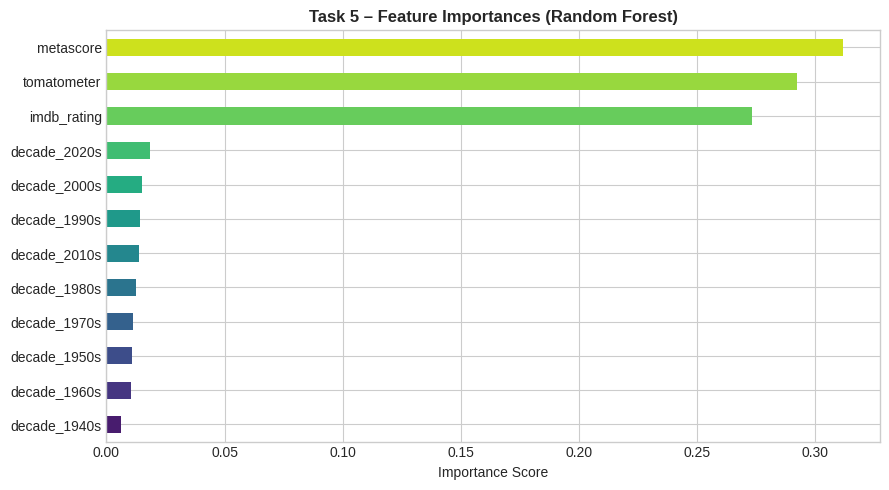

In [14]:

# ─────────────────────────────────────────────────────────────
# TASK 5 – Predictive Model: Predict dominant emotion
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TASK 5 — Predictive Model (Rating → Dominant Emotion)")
print("=" * 65)

# Build target: dominant f1 emotion per movie
df["dominant_emotion"] = df[f1_cols].idxmax(axis=1).str.replace("f1_", "")

# Features: the three rating sources + decade (one-hot)
features_df = df[["imdb_rating", "tomatometer", "metascore"]].copy()
decade_dummies = pd.get_dummies(df["decade"], prefix="decade")
features_df = pd.concat([features_df, decade_dummies], axis=1)

# Keep only emotions with ≥ 20 samples to keep model sensible
target = df["dominant_emotion"]
valid_emotions = target.value_counts()[target.value_counts() >= 20].index
mask = target.isin(valid_emotions)

X = features_df[mask].values
y = target[mask].values

print(f"\nSamples after filtering rare emotions: {len(X)}")
print(f"Emotion classes: {sorted(set(y))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest accuracy: {acc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Feature importance plot
importances = clf.feature_importances_
feat_names  = (["imdb_rating","tomatometer","metascore"]
               + list(decade_dummies.columns))
imp_series  = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(12)

fig2, ax = plt.subplots(figsize=(9, 5))
imp_series[::-1].plot(kind="barh", color=sns.color_palette("viridis", 12), ax=ax)
ax.set_title("Task 5 – Feature Importances (Random Forest)", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/task5_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("\nSaved: task5_feature_importance.png")

# Quick insight: which emotion does a high-rated modern film tend to be?
sample = np.array([[88, 92, 85, 0, 0, 0, 0, 0, 0, 0, 1]])  # 2010s, high ratings
# pad to match feature width
pad = np.zeros((1, features_df.shape[1] - sample.shape[1]))
sample_full = np.hstack([sample[:, :3], np.zeros((1, features_df.shape[1]-3))])
pred_emotion = clf.predict(sample_full)[0]
print(f"\nInsight – a high-rated 2010s film is predicted dominant emotion: '{pred_emotion}'")

print("\n" + "=" * 65)
print("All 5 tasks complete.")
print("Outputs saved to /mnt/user-data/outputs/")
print("=" * 65)